In [9]:
import pandas as pd
import glob

# Find the Excel file automatically (name is long, this avoids typos)
excel_file = glob.glob("tmdb_movies_2024_*_filtered.xlsx")[0]
print(f"Loading: {excel_file}")

df = pd.read_excel(excel_file)

print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns")
df.head()

Loading: tmdb_movies_2024_2026_filtered.xlsx
Loaded 2,059 rows and 30 columns


,id,title,original_title,release_date,status,runtime_minutes,genres,overview,tagline,vote_average,...,producers,top_10_cast,full_cast,keywords,homepage,imdb_id,poster_url,backdrop_url,adult,belongs_to_collection
0,83533,Avatar: Fire and Ash,Avatar: Fire and Ash,2025-12-17,Released,198,"Science Fiction, Adventure, Fantasy",In the wake of the devastating war against the...,The world of Pandora will change forever.,7.601,...,"James Cameron, Jon Landau","Sam Worthington, Zoe Saldaña, Sigourney Weaver...","Sam Worthington, Zoe Saldaña, Sigourney Weaver...","witch, clone, space war, tribe, sequel, alien,...",https://www.avatar.com/movies/avatar-fire-and-ash,tt1757678,https://image.tmdb.org/t/p/original/bRBeSHfGHw...,https://image.tmdb.org/t/p/original/u8DU5fkLoM...,False,Avatar Collection
1,324544,In the Lost Lands,In the Lost Lands,2025-02-27,Released,101,"Action, Fantasy, Western",A queen sends the powerful and feared sorceres...,She seeks the power to free her people.,6.368,...,"Constantin Werner, Jeremy Bolt, Dave Bautista,...","Milla Jovovich, Dave Bautista, Arly Jover, Ama...","Milla Jovovich, Dave Bautista, Arly Jover, Ama...","witch, dystopia, sorcery, betrayal, based on s...",https://inthelostlands.com,tt4419684,https://image.tmdb.org/t/p/original/dDlfjR7gll...,https://image.tmdb.org/t/p/original/oI5uHu7lrQ...,False,NaN
2,365177,Borderlands,Borderlands,2024-08-07,Released,101,"Action, Science Fiction, Comedy","Returning to her home planet, an infamous boun...",Chaos loves company.,5.590,...,"Avi Arad, Ari Arad, Erik Feig","Cate Blanchett, Kevin Hart, Edgar Ramírez, Jam...","Cate Blanchett, Kevin Hart, Edgar Ramírez, Jam...","outlaw, based on video game, unlikely friendsh...",https://borderlands.movie,tt4978420,https://image.tmdb.org/t/p/original/4JGoZu1ZKF...,https://image.tmdb.org/t/p/original/mKOBdgaEFg...,False,NaN
3,402431,Wicked,Wicked,2024-10-16,Released,162,"Drama, Romance, Fantasy","In the land of Oz, ostracized and misunderstoo...",Everyone deserves the chance to fly.,6.900,...,"Marc Platt, David Stone","Cynthia Erivo, Ariana Grande, Michelle Yeoh, J...","Cynthia Erivo, Ariana Grande, Michelle Yeoh, J...","witch, dancing, based on novel or book, fairy ...",https://www.wickedmovie.com,tt1262426,https://image.tmdb.org/t/p/original/xDGbZ0JJ3m...,https://image.tmdb.org/t/p/original/fyZ6SDUS4o...,False,Wicked Collection
4,413846,1992,1992,2024-08-29,Released,96,"Crime, Thriller, Action","In 1992, Mercer is desperately trying to rebui...",Every city has a breaking point.,6.921,...,"Maurice Fadida, Ariel Vromen, Adam Kolbrenner,...","Tyrese Gibson, Scott Eastwood, Ray Liotta, Dyl...","Tyrese Gibson, Scott Eastwood, Ray Liotta, Dyl...","looting, race politics, street riots, based on...",https://www.lionsgate.com/movies/1992,tt4959750,https://image.tmdb.org/t/p/original/tPvFmQZM5H...,https://image.tmdb.org/t/p/original/pbmlCNeOwv...,False,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2059 non-null   int64  
 1   title                  2058 non-null   object 
 2   original_title         2058 non-null   object 
 3   release_date           2059 non-null   object 
 4   status                 2059 non-null   object 
 5   runtime_minutes        2059 non-null   int64  
 6   genres                 1934 non-null   object 
 7   overview               1654 non-null   object 
 8   tagline                1248 non-null   object 
 9   vote_average           2059 non-null   float64
 10  vote_count             2059 non-null   int64  
 11  popularity             2059 non-null   float64
 12  budget                 2059 non-null   int64  
 13  revenue                2059 non-null   int64  
 14  original_language      2059 non-null   object 
 15  spok

In [11]:
df.columns

Index(['id', 'title', 'original_title', 'release_date', 'status',
       'runtime_minutes', 'genres', 'overview', 'tagline', 'vote_average',
       'vote_count', 'popularity', 'budget', 'revenue', 'original_language',
       'spoken_languages', 'production_companies', 'production_countries',
       'director', 'writers', 'producers', 'top_10_cast', 'full_cast',
       'keywords', 'homepage', 'imdb_id', 'poster_url', 'backdrop_url',
       'adult', 'belongs_to_collection'],
      dtype='object')

In [12]:
df["ROI"] = (df["revenue"] - df["budget"]) / df["budget"]
df[["revenue", "budget", "ROI"]].head()

,revenue,budget,ROI
0,1490477656,350000000,3.258508
1,4755330,55000000,-0.913539
2,33017367,115000000,-0.712892
3,758827029,150000000,4.058847
4,2900000,6500000,-0.553846


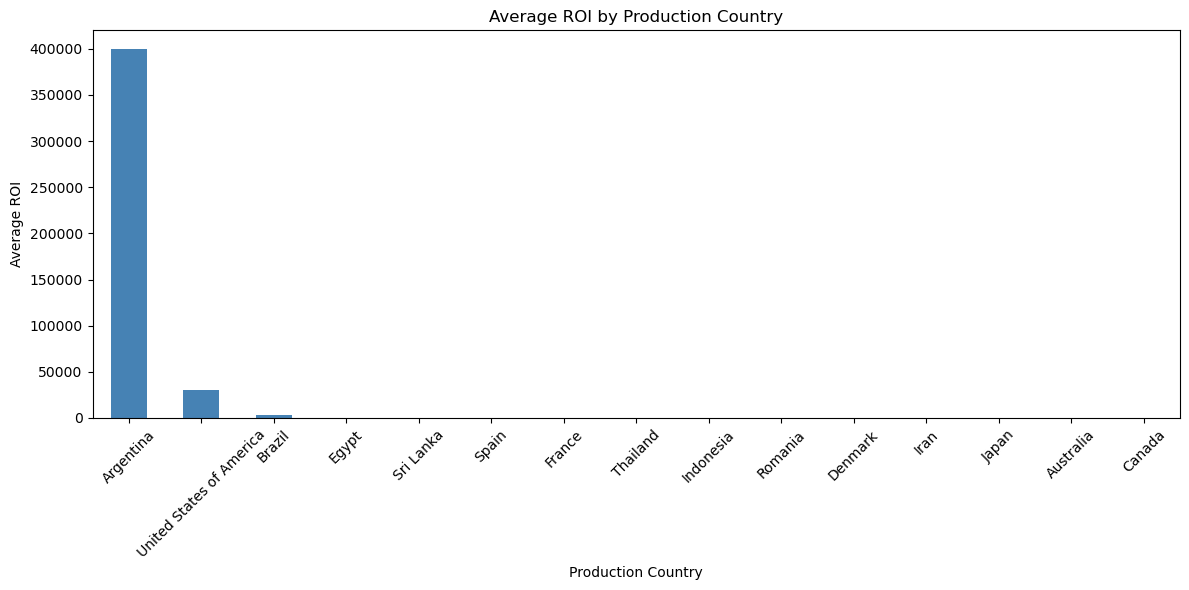

prod_country
Argentina                   400007.095091
United States of America     29828.055519
Brazil                        3697.494592
Egypt                          165.032354
Sri Lanka                       49.001884
Spain                           47.713888
France                          40.010727
Thailand                        38.690859
Indonesia                       16.244386
Romania                         14.118337
Denmark                         13.834989
Iran                            10.514352
Japan                            9.854248
Australia                        9.595314
Canada                           9.063529
Name: ROI, dtype: float64

In [13]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

if "ROI" not in df.columns:
    df["ROI"] = np.where(
        df["budget"].ne(0),
        (df["revenue"] - df["budget"]) / df["budget"],
        np.nan,
    )

country_roi = (
    df.assign(prod_country=df["production_countries"].fillna("").str.split(","))
    .explode("prod_country")
    .assign(prod_country=lambda x: x["prod_country"].str.strip())
    .loc[lambda x: x["prod_country"].ne("")]
    [["prod_country", "ROI"]]
)

avg_roi_by_country = (
    country_roi.groupby("prod_country")["ROI"]
    .mean()
    .dropna()
    .sort_values(ascending=False)
)

top_countries = avg_roi_by_country.head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_countries.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Average ROI by Production Country")
ax.set_xlabel("Production Country")
ax.set_ylabel("Average ROI")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

top_countries

Highest percentage genre: Drama (18.97%)
Lowest percentage genre: TV Movie (0.26%)


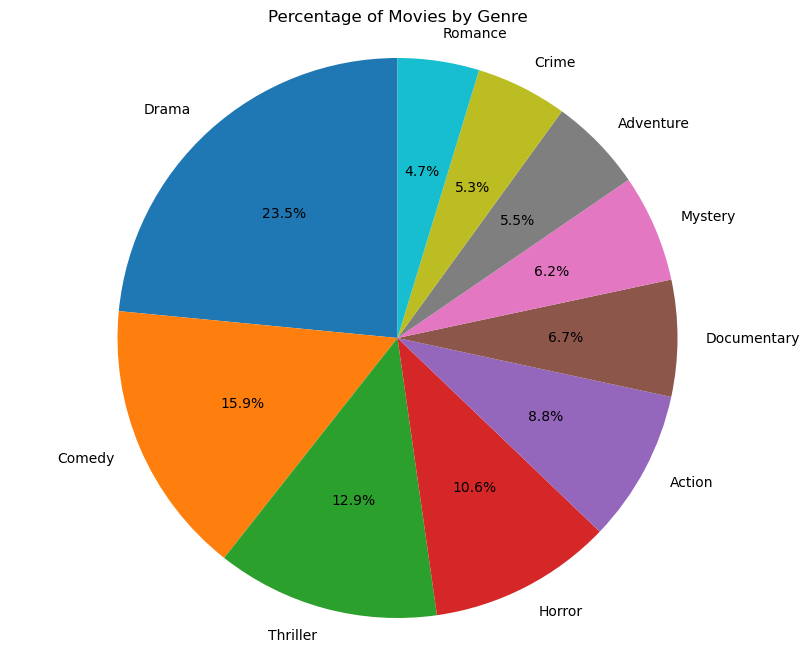

genres
Drama          18.973162
Comedy         12.858810
Thriller       10.408401
Horror          8.564761
Action          7.094516
Documentary     5.437573
Mystery         5.017503
Adventure       4.410735
Crime           4.270712
Romance         3.803967
Name: count, dtype: float64

In [14]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

# Explode the comma-separated genres into one row per genre
genre_series = (
    df["genres"]
    .fillna("")
    .astype(str)
    .str.split(",")
    .explode()
    .str.strip()
    .loc[lambda s: s != ""]
)

# Count each genre and convert to percentages
genre_counts = genre_series.value_counts()
genre_pct = genre_counts / genre_counts.sum() * 100

# Show max and min genres
max_genre = genre_pct.idxmax()
min_genre = genre_pct.idxmin()
max_pct = genre_pct.max()
min_pct = genre_pct.min()

print(f"Highest percentage genre: {max_genre} ({max_pct:.2f}%)")
print(f"Lowest percentage genre: {min_genre} ({min_pct:.2f}%)")

# Plot pie chart
plt.figure(figsize=(10, 8))
plt.pie(
    genre_pct.head(10).values,
    labels=genre_pct.head(10).index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.6,
)
plt.title("Percentage of Movies by Genre")
plt.axis("equal")
plt.show()

genre_pct.head(10)

In [15]:
%matplotlib inline
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Budget-controlled hypothesis test:
# H0: controlling for budget, franchise status has no relationship with revenue
# H1: franchise films out-earn budget-matched standalone films

sub = df[['budget', 'revenue', 'belongs_to_collection']].copy().dropna()
sub = sub[(sub['budget'] > 0) & (sub['revenue'] > 0)].copy()

# 1 = belongs to a collection; 0 = standalone
sub['franchise'] = sub['belongs_to_collection'].notna().astype(int)
sub['log_budget'] = np.log1p(sub['budget'])
sub['log_revenue'] = np.log1p(sub['revenue'])

X = sm.add_constant(sub[['log_budget', 'franchise']])
y = sub['log_revenue']
model = sm.OLS(y, X).fit()

print('rows_used =', len(sub))
print('budget_coef =', model.params['log_budget'])
print('franchise_coef =', model.params['franchise'])
print('franchise_p_value =', model.pvalues['franchise'])
print('r_squared =', model.rsquared)

# Approximate multiplicative premium from regression coefficient
prem = (np.exp(model.params['franchise']) - 1) * 100
print('approx_revenue_premium_percent =', round(prem, 4))

model.summary()

rows_used = 147
budget_coef = 1.0108487754143634
franchise_coef = 0.7479182667737767
franchise_p_value = 0.32630807431197373
r_squared = 0.7749244993343377
approx_revenue_premium_percent = 111.2598


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            log_revenue   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     499.2
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           8.30e-49
Time:                        15:35:02   Log-Likelihood:                -281.69
No. Observations:                 147   AIC:                             567.4
Df Residuals:                     145   BIC:                             573.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
log_budget     1.0108      0.045     22.343      0.000       0.921       1.100
franchise      0.7479      0.759      0.985      0.326      -0.753       2.249
==============================================================================
Omnibus:                       18.172   Durbin-Watson:                   2.025
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               36.472
Skew:                          -0.534   Prob(JB):                     1.20e-08
Kurtosis:                       5.194   Cond. No.                         93.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

rows_used = 2059
slope = 0.9360941178412436
intercept = 0.40265398711025213
r = 0.9155748082891364
p_value = 0.0
stderr = 0.009065549257085163


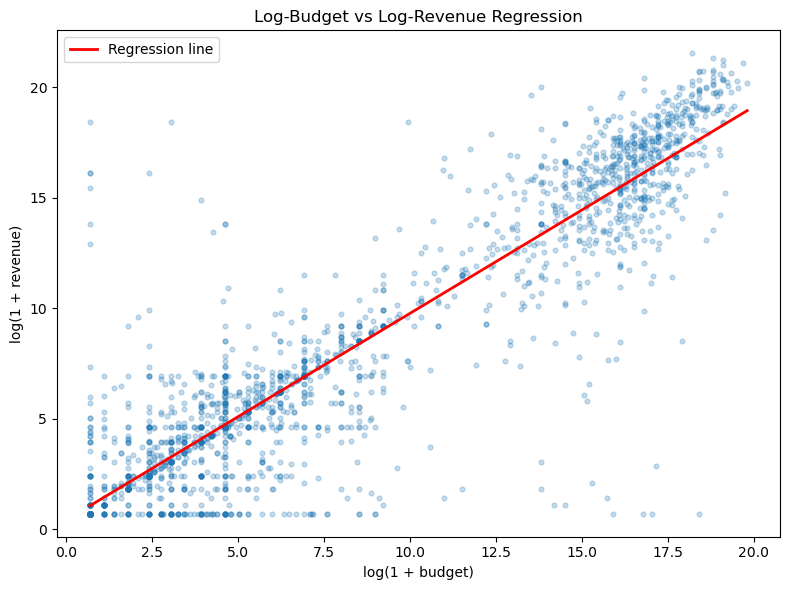

LinregressResult(slope=0.9360941178412436, intercept=0.40265398711025213, rvalue=0.9155748082891364, pvalue=0.0, stderr=0.009065549257085163, intercept_stderr=0.09505150057803703)

In [16]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Filter to positive, interpretable records
sub = df[['budget', 'revenue']].copy().dropna()
sub = sub[(sub['budget'] > 0) & (sub['revenue'] > 0)]

x = np.log1p(sub['budget'])
y = np.log1p(sub['revenue'])

res = stats.linregress(x, y)
print('rows_used =', len(sub))
print('slope =', res.slope)
print('intercept =', res.intercept)
print('r =', res.rvalue)
print('p_value =', res.pvalue)
print('stderr =', res.stderr)

# Scatter plot with fitted regression line
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.25, s=12)

x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = res.intercept + res.slope * x_fit
plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Regression line')

plt.title('Log-Budget vs Log-Revenue Regression')
plt.xlabel('log(1 + budget)')
plt.ylabel('log(1 + revenue)')
plt.legend()
plt.tight_layout()
plt.show()

res

In [17]:
%matplotlib inline
import numpy as np
import pandas as pd
import statsmodels.api as sm

sub = df[['budget', 'revenue', 'belongs_to_collection']].copy().dropna()
sub = sub[(sub['budget'] > 0) & (sub['revenue'] > 0)].copy()

sub['franchise'] = sub['belongs_to_collection'].notna().astype(int)
sub['log_budget'] = np.log1p(sub['budget'])
sub['log_revenue'] = np.log1p(sub['revenue'])

X = sm.add_constant(sub[['log_budget', 'franchise']])
y = sub['log_revenue']
model = sm.OLS(y, X).fit()

print('rows_used =', len(sub))
print('budget_coef =', model.params['log_budget'])
print('franchise_coef =', model.params['franchise'])
print('franchise_p_value =', model.pvalues['franchise'])
print('r_squared =', model.rsquared)

prem = (np.exp(model.params['franchise']) - 1) * 100
print('approx_revenue_premium_percent =', round(prem, 4))

model.summary()

rows_used = 147
budget_coef = 1.0108487754143634
franchise_coef = 0.7479182667737767
franchise_p_value = 0.32630807431197373
r_squared = 0.7749244993343377
approx_revenue_premium_percent = 111.2598


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            log_revenue   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     499.2
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           8.30e-49
Time:                        15:35:02   Log-Likelihood:                -281.69
No. Observations:                 147   AIC:                             567.4
Df Residuals:                     145   BIC:                             573.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
log_budget     1.0108      0.045     22.343      0.000       0.921       1.100
franchise      0.7479      0.759      0.985      0.326      -0.753       2.249
==============================================================================
Omnibus:                       18.172   Durbin-Watson:                   2.025
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               36.472
Skew:                          -0.534   Prob(JB):                     1.20e-08
Kurtosis:                       5.194   Cond. No.                         93.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

rows_used = 1600
slope = 0.08084871937265907
intercept = 4.291378331258303
r = 0.7419281437777763
p_value = 9.849968444304115e-280
stderr = 0.0018277144812277218


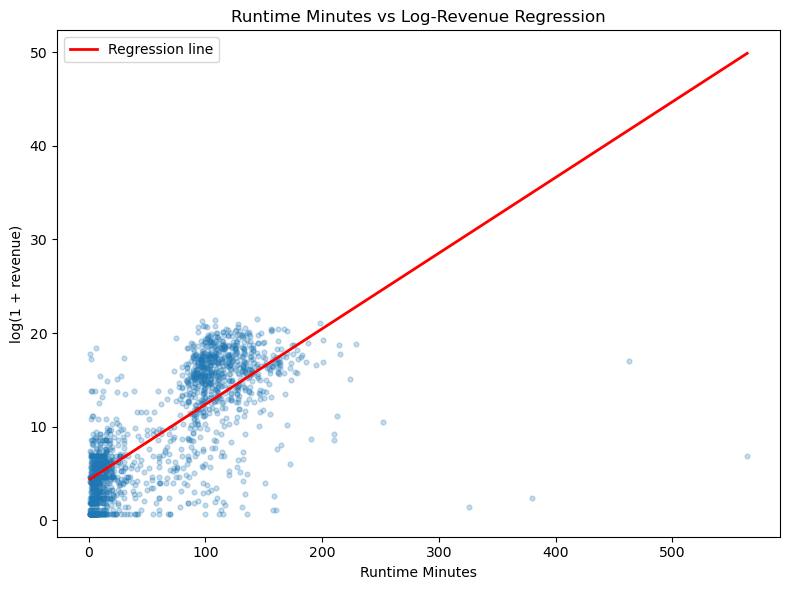

LinregressResult(slope=0.08084871937265907, intercept=4.291378331258303, rvalue=0.7419281437777763, pvalue=9.849968444304115e-280, stderr=0.0018277144812277218, intercept_stderr=0.1594518529474868)

In [18]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Regression test: runtime_minutes -> revenue
sub = df[['runtime_minutes', 'revenue']].copy().dropna()
sub = sub[(sub['runtime_minutes'] > 0) & (sub['revenue'] > 0)]

x = sub['runtime_minutes']
y = np.log1p(sub['revenue'])

res = stats.linregress(x, y)
print('rows_used =', len(sub))
print('slope =', res.slope)
print('intercept =', res.intercept)
print('r =', res.rvalue)
print('p_value =', res.pvalue)
print('stderr =', res.stderr)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.25, s=12)

x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = res.intercept + res.slope * x_fit
plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Regression line')

plt.title('Runtime Minutes vs Log-Revenue Regression')
plt.xlabel('Runtime Minutes')
plt.ylabel('log(1 + revenue)')
plt.legend()
plt.tight_layout()
plt.show()

res

In [19]:
%matplotlib inline
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Parse genres and create one row per genre per movie
rows = []
for _, row in df[['genres', 'revenue']].iterrows():
    genres = [g.strip() for g in str(row['genres']).split(',') if g.strip()]
    for genre in genres:
        rows.append({'genre': genre, 'revenue': row['revenue']})

genre_df = pd.DataFrame(rows)

# Keep only positive revenue values and use log-transform for a more stable ANOVA
genre_df = genre_df[genre_df['revenue'] > 0].copy()
genre_df['log_revenue'] = np.log1p(genre_df['revenue'])

# Limit to genres with enough observations
valid = genre_df.groupby('genre').filter(lambda x: len(x) >= 50)

# Overall ANOVA
samples = [group['log_revenue'].values for _, group in valid.groupby('genre')]
f_stat, p_value = stats.f_oneway(*samples)

print('Overall ANOVA')
print('genres_used =', len(valid['genre'].unique()))
print('f_stat =', f_stat)
print('p_value =', p_value)
print('\nMean revenue by genre:')
print(valid.groupby('genre')['revenue'].mean().sort_values(ascending=False).head(10))

# Post-hoc Tukey HSD test
label = valid['genre']
value = valid['log_revenue']

posthoc = pairwise_tukeyhsd(endog=value, groups=label, alpha=0.05)
print('\nTukey HSD post-hoc results:')
print(posthoc)


Overall ANOVA
genres_used = 17
f_stat = 24.03267840754585
p_value = 1.1366294919531443e-68

Mean revenue by genre:
genre
Adventure          1.340676e+08
Animation          1.244635e+08
Science Fiction    1.029079e+08
Family             1.004002e+08
Fantasy            9.842981e+07
Action             7.084467e+07
Comedy             3.972442e+07
Crime              2.500253e+07
Romance            2.462624e+07
History            2.454840e+07
Name: revenue, dtype: float64

Tukey HSD post-hoc results:
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------
         Action       Adventure  -0.2104    1.0 -2.1767  1.7558  False
         Action       Animation  -0.8678 0.9973 -3.1772  1.4416  False
         Action          Comedy  -3.2914    0.0  -4.808 -1.7749   True
         Action           Crime  -1.8222 0.1171 -3.8082  0.1639  False
   

rows_used = 1107
slope = -0.5433815895977792
intercept = 8.224116086045479
r = -0.36848579151400696
p_value = 6.247649954651219e-37
stderr = 0.04123962845102361


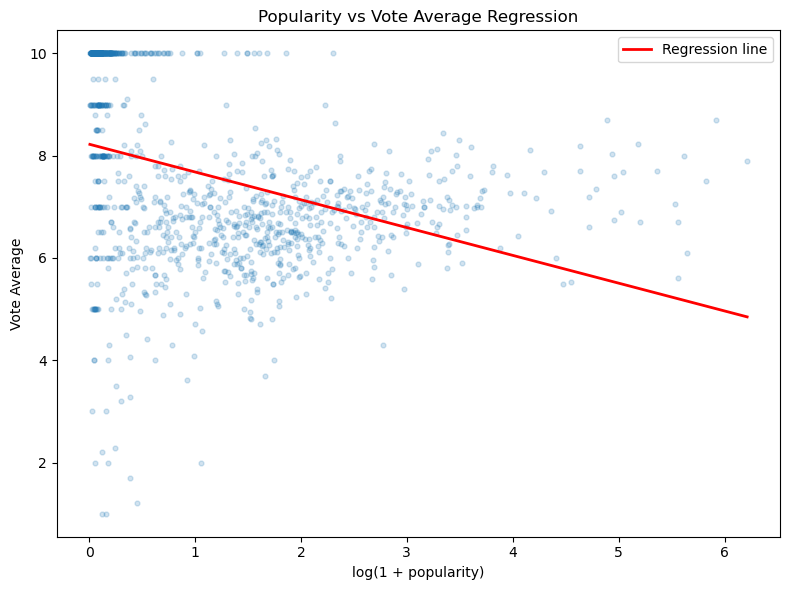

LinregressResult(slope=-0.5433815895977792, intercept=8.224116086045479, rvalue=-0.36848579151400696, pvalue=6.247649954651219e-37, stderr=0.04123962845102361, intercept_stderr=0.0687448361062423)

In [20]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Hypothesis test: popularity -> vote_average
sub = df[['popularity', 'vote_average']].copy().dropna()
sub = sub[(sub['popularity'] > 0) & (sub['vote_average'] > 0)].copy()

x = np.log1p(sub['popularity'])
y = sub['vote_average']

res = stats.linregress(x, y)
print('rows_used =', len(sub))
print('slope =', res.slope)
print('intercept =', res.intercept)
print('r =', res.rvalue)
print('p_value =', res.pvalue)
print('stderr =', res.stderr)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.2, s=12)

x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = res.intercept + res.slope * x_fit
plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Regression line')

plt.title('Popularity vs Vote Average Regression')
plt.xlabel('log(1 + popularity)')
plt.ylabel('Vote Average')
plt.legend()
plt.tight_layout()
plt.show()

res

In [21]:
import pandas as pd
import glob

# Find the Excel file automatically
excel_file = glob.glob("tmdb_movies_2024_*.xlsx")[0]
print(f"Loading: {excel_file}")

df = pd.read_excel(excel_file)

# Convert budget/revenue to numeric and remove rows with 0 or missing values
df["budget"] = pd.to_numeric(df["budget"], errors="coerce")
df["revenue"] = pd.to_numeric(df["revenue"], errors="coerce")

df = df[(df["budget"] > 0) & (df["revenue"] > 0)].copy()

print(f"Rows after filtering: {df.shape[0]:,}")

# Save a cleaned copy
output_file = excel_file.replace(".xlsx", "_filtered.xlsx")
df.to_excel(output_file, index=False)
print(f"Saved cleaned data to {output_file}")

Loading: tmdb_movies_2024_2026_filtered.xlsx
Rows after filtering: 2,059
Saved cleaned data to tmdb_movies_2024_2026_filtered_filtered.xlsx
